# Loaded-Dice — can a moving-average crossover beat a coin? 🎲
### The 5-minute SMA(5/10) scalp, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

Here's a recipe you'll find in a thousand day-trading videos: on the 5-minute chart, when the fast 5-bar average crosses the slow 10-bar average, jump in the way it crossed, grab a few dollars, and do it again — *all day*. It's pitched as a **dice roll with the odds nudged your way** by the trend. This notebook asks the only question that matters: is the die actually loaded, or is it just a coin wearing a costume?

> 📓 **This is the plain-language layer.** Want the t-stats, the bootstrap intervals and the cost maths? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from loaded_dice import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA", "ES=F", "NQ=F"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.crossover_entries(b["close"])
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real 5m cache present:" , HAVE_REAL)


real 5m cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Does the crossover point the right way? | **No.** With a fair (symmetric) target & stop it wins **49.6%** of the time — a coin. |
| Does it beat an actual coin flip? | **No.** A random-direction entry on the *same* trades does just as well (better, by a hair). |
| 'But my win-rate is 90%+!' | That's the trap. A tiny target with no real stop manufactures a **93.5%** win-rate — and a tail that eats it. |
| Could you trade it? | **No.** At ~11 trades/day, costs turn the coin into a **-40%/yr** loser. |

> 💡 The trend doesn't load the die. The high win-rate people brag about is an accounting trick of *where they put the exit*, not an edge.

## 1 · The claim

> *"Plot SMA(5) and SMA(10) on a 5-minute chart. Go **long** when 5 crosses **above** 10, **short** when it crosses **below**. Take a few dollars of profit and repeat. The moving averages keep you on the right side of the short-term trend — it's a coin flip, but a coin flip with an edge."*

It's an honest-sounding idea. Markets do trend sometimes, and a crossover is the simplest possible trend detector. The bet is that **very-short-term momentum** leaks enough information into the next few minutes to tilt a near-random outcome your way.

## 2 · So what?

If it's true, it's a money printer: a simple, mechanical, all-day rule anyone can run. If it's false, thousands of people are paying spreads and commissions ~11 times a day to play a coin flip with a house edge **against** them. The difference between those two worlds is one honest test — so let's run it.

## 3 · How would we even know?

Two rules keep us honest:

1. **Make the bet symmetric.** If your profit target and your stop are the same distance away (here: one *ATR* — the bar's typical range — on each side), then a coin scores zero. Only a *real* sense of direction can beat that. Asymmetric exits (small target, far stop) hide the truth behind a pretty win-rate.
2. **Race it against an actual coin.** Take the exact same entry moments and flip a coin for the direction. If the crossover knows something, it beats the coin. If it doesn't, it won't.

We run it on **eight liquid markets** (SPY, QQQ, IWM, AAPL, TSLA, NVDA, ES, NQ) over ~60 days of 5-minute bars — the most history the data vendor gives at this resolution.

## 4 · The teardown — let's actually look

**First, the trap that fools everyone.** Here's what happens to your *win-rate* and your *risk* as you shrink the profit target and push the stop further away — the literal 'grab a few dollars and let it ride' recipe:

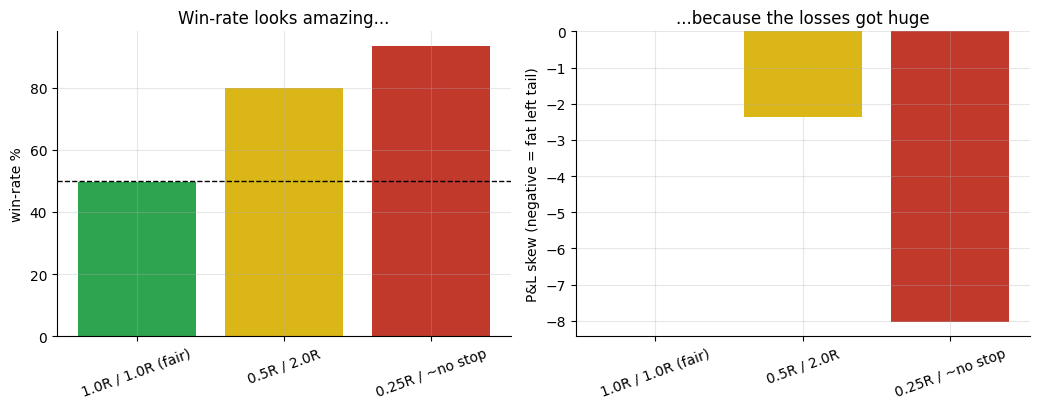

,exit rule,win-rate %,P&L skew,mean bps/trade
0,1.0R / 1.0R (fair),49.64,-0.00,-0.39
1,0.5R / 2.0R,80.08,-2.37,0.40
2,0.25R / ~no stop,93.50,-8.03,0.47


In [2]:
rows = []
labels = [('1.0R / 1.0R (fair)', 1.0, 1.0), ('0.5R / 2.0R', 0.5, 2.0),
          ('0.25R / ~no stop', 0.25, 8.0)]
if HAVE_REAL:
    for lbl, tp, sl in labels:
        s = st.summarize(pooled(tp, sl, 0.0), 'ret_gross')
        rows.append((lbl, s['win_rate']*100, s['skew'], s['mean_bps']))
else:
    rows = [('1.0R / 1.0R (fair)', R['cross_win'], R['cross_skew'], R['cross_mean']),
            ('0.5R / 2.0R', R['naive14_win'], R['naive14_skew'], R['naive14_mean']),
            ('0.25R / ~no stop', R['nostop_win'], R['nostop_skew'], R['nostop_mean'])]
tbl = pd.DataFrame(rows, columns=['exit rule', 'win-rate %', 'P&L skew', 'mean bps/trade'])

fig, ax = plt.subplots(1, 2, figsize=(10.5, 4.2))
ax[0].bar(tbl['exit rule'], tbl['win-rate %'], color=[GREEN, AMBER, RED])
ax[0].axhline(50, ls='--', c='k', lw=1); ax[0].set_ylabel('win-rate %')
ax[0].set_title('Win-rate looks amazing...'); ax[0].tick_params(axis='x', rotation=20)
ax[1].bar(tbl['exit rule'], tbl['P&L skew'], color=[GREEN, AMBER, RED])
ax[1].set_ylabel('P&L skew (negative = fat left tail)')
ax[1].set_title('...because the losses got huge'); ax[1].tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()
tbl.round(2)

The 'no stop' version wins **~93%** of its trades. It also has a P&L skew of about **−8**: almost every trade banks a sliver, and the rare loser is a catastrophe. On SPY that arm exits **477 take-profits, 19 flat-at-close, and just 1 stop** — picking up pennies in front of a steamroller. A high win-rate is **not** evidence of an edge; it's a choice about where you hide the loss.

**Now the honest test: the fair 1:1 bet, crossover vs a coin.**

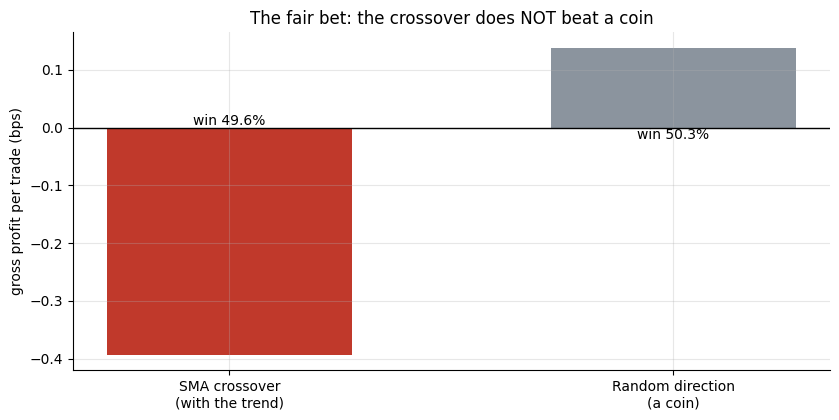

crossover: -0.39 bps/trade   |   coin: +0.14 bps/trade


In [3]:
if HAVE_REAL:
    c = st.summarize(pooled(1, 1, 0.0), 'ret_gross')
    r = st.summarize(pooled(1, 1, 0.0, seed=72), 'ret_gross')
    cm, cw, rm, rw = c['mean_bps'], c['win_rate']*100, r['mean_bps'], r['win_rate']*100
else:
    cm, cw, rm, rw = R['cross_mean'], R['cross_win'], R['rand_mean'], R['rand_win']
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['SMA crossover\n(with the trend)', 'Random direction\n(a coin)'],
              [cm, rm], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross profit per trade (bps)')
ax.set_title('The fair bet: the crossover does NOT beat a coin')
for b, w in zip(bars, [cw, rw]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='bottom' if b.get_height()<0 else 'top')
plt.tight_layout(); plt.show()
print(f'crossover: {cm:+.2f} bps/trade   |   coin: {rm:+.2f} bps/trade')

On the real tape the crossover earns **-0.39 bps per trade** — essentially zero, and if anything slightly *negative*. The coin earns **+0.14**. They are the same bet. The trend filter adds nothing.

> 💡 Why? At the 5-minute scale, prices don't really trend — they jiggle. The little wiggles that make a 5/10 crossover fire are mostly noise and 'bid-ask bounce', so by the time you've entered, the next wiggle is just as likely to go against you.

## 5 · The verdict

- **Signal — None.** The crossover direction carries no real information; it loses a (statistically invisible) sliver and ties a coin.
- **Tradability — Mirage.** Even if it were flat, ~11 trades/day of costs make it a **-40%/yr** loser.
- **Beats a coin? — Busted.** The 'loaded die' isn't loaded. The famous 90% win-rate is a trick of the exit, not a glimpse of the future.

## 6 · Could you actually trade it?

This is where even a *flat* coin goes to die. Add a realistic round-trip cost and run the fair version ~11 times a day:

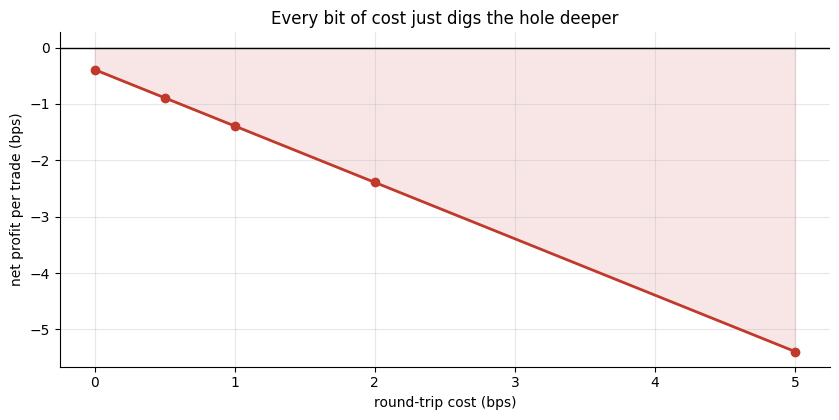

gross is already -0.39 bps — there is no positive break-even cost.


In [4]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    net = [st.summarize(pooled(1, 1, c), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [R['cross_mean'], R['net05'], R['net10'], R['net20'], R['cross_mean']-5+0.39]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Every bit of cost just digs the hole deeper')
plt.tight_layout(); plt.show()
print(f'gross is already {net[0]:+.2f} bps — there is no positive break-even cost.')

The line starts below zero and only falls. Because the gross edge is already negative, **there is no cost low enough to make it work** — the usual 'it dies at the costs line' story doesn't even apply, because it was never alive.

## 7 · Going further 🚪

- **Is *anything* findable at 5 minutes?** The companion notebook shows a synthetic control: when we *plant* real momentum in a fake tape, this exact rule finds it. So the machine works — the real market just has nothing to find here.
- **The opposite bet.** If short-term moves *reverse* rather than continue, you'd fade the crossover, not follow it — that's [Study 32 — Rip-Tide](../../32-rip-tide/).
- **One timeframe up.** The daily 50/200 'golden cross' is [Study 21 — Fools-Gold](../../21-fools-gold/) — same family, same ending.

*Think the die really is loaded? Fork this, change the timeframe or the instrument, and show a fair-bet edge that beats the coin and clears the costs. That's the bar.*